In [5]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models

# 1. 전처리 도구 정의(ImageNet 표준 규격)
preprocess = transforms.Compose([
    transforms.Resize(520),          # 모델 권장 입력 크기(최소 변 길이: 520)
    transforms.ToTensor(),            # [0, 255] -> [0.0, 1.0] tensor 변환
    transforms.Normalize(             # ImageNet 데이터셋 평균/표준편차로 normalize
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# 2. Loading Image
img_path = "../images/object_detection/my_photo.jpeg"
input_image = Image.open(img_path).convert('RGB')

# 3. 전처리 적용 & 배치 차원 추가
input_tensor = preprocess(input_image)
input_batch = input_tensor.unsqueeze(0) # (3, H, W) -> (1, 3, H, W)

# 4. Loading DeepLabV3 model(using ResNet-101 backbone)
weights = models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = models.segmentation.deeplabv3_resnet101(weights=weights)

# 5. Moving Device(MPS or CPU)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
input_batch = input_batch.to(device)
model.to(device)

print(f"Finished Preprocessing! The size of the input tensor: {input_batch.shape}")


Finished Preprocessing! The size of the input tensor: torch.Size([1, 3, 520, 693])


In [6]:
# 1. Turn the model to evaluation mode
model.eval()

# 2. 기울기 계산 비활성화(메모리 절약)
with torch.no_grad():
    raw_output = model(input_batch)['out']
    output = raw_output[0]
# 각 픽셀에서 21개의 채널 중 최댓값의 인덱스(0~20) 추출
output_prediction = output.argmax(0)

print(f"Output 선언 완료! Size: {output.shape}")

Output 선언 완료! Size: torch.Size([21, 520, 693])


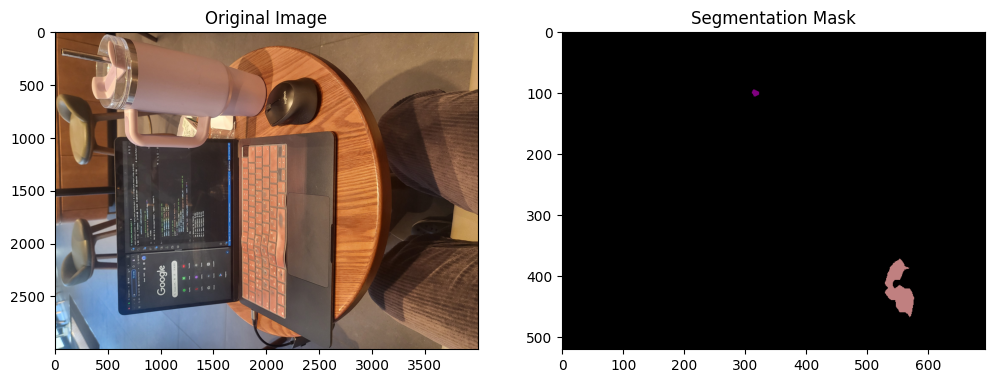

Saved the Image: ../images/semantic_segmentation/result_deeplabv3.png


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

# PASCAL VOC 클래스별 표준 컬러 팔레트 정의 (R, G, B)
palette = torch.tensor([
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
    [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
    [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
    [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128]
])

# 인덱스 지도를 RGB 이미지로 변환(cpu로 옮겨 처리)
rgb_mask = palette[output_prediction.cpu()].numpy().astype("uint8")

# 결과 시각화
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(input_image)

plt.subplot(1, 2, 2)
plt.title("Segmentation Mask")
plt.imshow(rgb_mask)

# 결과 출력 및 이미지 생성
save_path = "../images/semantic_segmentation/result_deeplabv3.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

print(f"Saved the Image: {save_path}")


인식률이 매우 낮음.
예상 이유 1. 해당 사진이 반시계방향으로 90도 회전된 상태기 때문
예상 이유 2. DeepLabV3의 인식 가능한 클래스가 21개로 매우 한정되어 있음

-> 개선 및 효과 비교를 위해 1번과 2번을 순차적으로 적용할 예정.

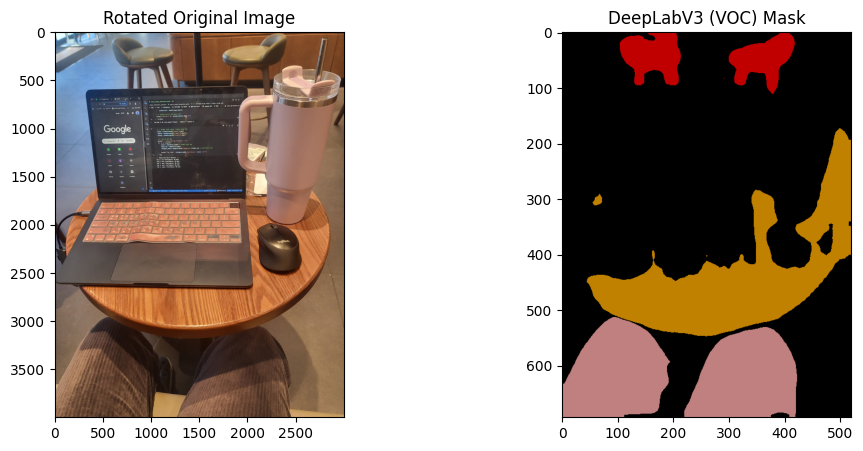

In [8]:
# Improved Version 1
# 기존 DeepLabV3 model 유지, image의 방향만 정방향으로 회전시킨 후 결과 비교

import torch
from torchvision import transforms, models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. 모델 로드 및 설정 (기존과 동일)
weights = models.segmentation.DeepLabV3_ResNet101_Weights.DEFAULT
model = models.segmentation.deeplabv3_resnet101(weights=weights)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model.to(device)
model.eval()

# 2. 전처리 파이프라인 (기존과 동일)
preprocess = transforms.Compose([
    transforms.Resize(520),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 3. 이미지 로드 및 회전 적용 (업데이트된 부분)
img_path = "../images/object_detection/my_photo.jpeg"
# expand=True(회전 시 이미지가 잘려나가지 않게 보존)
input_image = Image.open(img_path).convert("RGB").rotate(-90, expand=True) 

# 4. 텐서 변환 및 추론
input_batch = preprocess(input_image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_batch)['out'][0]

# 5. 시각화 (색상 팔레트)
output_predictions = output.argmax(0)

palette = torch.tensor([
    [0, 0, 0], [128, 0, 0], [0, 128, 0], [128, 128, 0], [0, 0, 128],
    [128, 0, 128], [0, 128, 128], [128, 128, 128], [64, 0, 0], [192, 0, 0],
    [64, 128, 0], [192, 128, 0], [64, 0, 128], [192, 0, 128], [64, 128, 128],
    [192, 128, 128], [0, 64, 0], [128, 64, 0], [0, 192, 0], [128, 192, 0],
    [0, 64, 128]
])

rgb_mask = palette[output_predictions.cpu()].numpy().astype("uint8")

# 6. 결과 출력 및 저장
save_dir = "../images/semantic_segmentation"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.title("Rotated Original Image")
plt.imshow(input_image)

plt.subplot(1, 2, 2)
plt.title("DeepLabV3 (VOC) Mask")
plt.imshow(rgb_mask)

save_path = os.path.join(save_dir, "result_deeplabv3_rotated.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)
plt.show()

Improved Version 1이 기존보다 향상된 객체 인식률을 보임
근거 1. 분홍색 면적(leg)의 증가
근거 2. 노란색 면적(table)의 출현
근거 3. 빨간색 면적(chair)의 출현

-> 사진의 회전 여부는 DeepLabV3의 인식률에 영향을 미침.

이미지가 저장되었습니다: ../images/semantic_segmentation/result_maskrcnn_coco_rotated.png


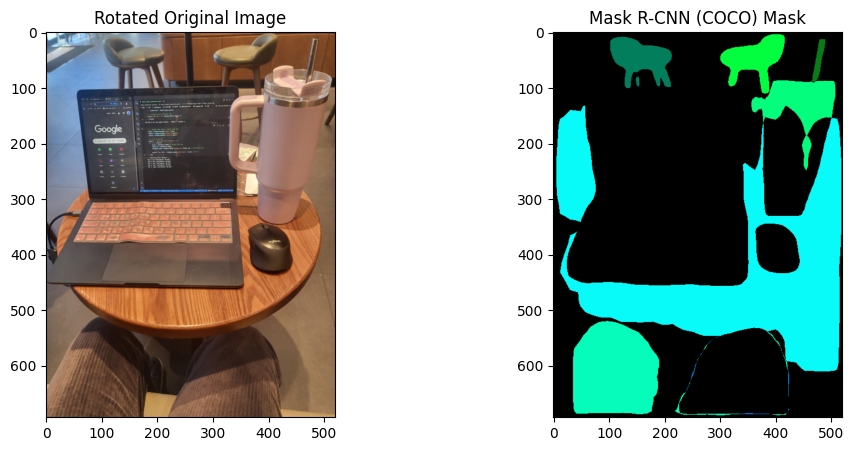

In [11]:
# Improved Version 2
# 기존 DeepLabV3 model(21개 클래스)에서 COCO model(80개 클래스)로 교체
# image의 방향도 정방향으로 회전시킨 후 Improved Version 1과 결과 비교

import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_segmentation_masks
import torchvision.transforms.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. 모델 준비 (COCO 기반 Mask R-CNN)(업데이트된 부분)
device = torch.device("cpu")
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = maskrcnn_resnet50_fpn(weights=weights).to(device)
model.eval()

# 2. 이미지 로드 및 회전 적용 (기존과 동일)
img_path = "../images/object_detection/my_photo.jpeg"
# expand=True(회전 시 이미지가 잘려나가지 않게 보존)
input_image = Image.open(img_path).convert("RGB").rotate(-90, expand=True) 

# 변인 통제: 실험 1과 완전히 동일한 전처리 크기 적용
resize_transform = transforms.Resize(520)
input_image = resize_transform(input_image)

# 3. 전처리 (Mask R-CNN용 텐서 변환)
image_tensor = F.pil_to_tensor(input_image)
input_batch = F.convert_image_dtype(image_tensor, dtype=torch.float).unsqueeze(0).to(device)

# 4. 추론
with torch.no_grad():
    output = model(input_batch)[0]

# 5. 신뢰도 0.7 이상 필터링 및 시각화
threshold = 0.7
keep_indices = output['scores'] > threshold
masks = output['masks'][keep_indices].squeeze(1) > 0.5

# 밝고 눈에 띄는 색상 팔레트 직접 정의 (PIL Color 이름 지원)
# 개수가 부족하면 반복해서 사용됩니다.
bright_colors = [
    "cyan",    # 민트색
    "lime",    # 형광 연두색
    "magenta", # 자주색
    "yellow",  # 노란색
    "red",     # 빨간색
    "dodgerblue" # 밝은 파란색
]

# 기존 버전의 포맷 유지를 위해 검은색 배경 생성
_, H, W = image_tensor.shape
black_canvas = torch.zeros((3, H, W), dtype=torch.uint8)

# mask를 불투명도 100%(alpha=1.0)으로 색칠
rgb_mask_tensor = draw_segmentation_masks(black_canvas, masks=masks, alpha=1.0)
rgb_mask_image = F.to_pil_image(rgb_mask_tensor)

# 6. 결과 출력 및 저장
save_dir = "../images/semantic_segmentation"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(12, 5))

# Left: 회전된 원본 이미지
plt.subplot(1, 2, 1)
plt.title("Rotated Original Image")
plt.imshow(input_image)

# Right: 검은 배경의 COCO mask
plt.subplot(1, 2, 2)
plt.title("Mask R-CNN (COCO) Mask")
plt.imshow(rgb_mask_image)

# 파일 저장
save_path = os.path.join(save_dir, "result_maskrcnn_coco_rotated.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)

print(f"이미지가 저장되었습니다: {save_path}")
plt.show()

예상과 달리 Improved Version 2가 Improved Version 1보다 퇴보함 인식률을 보임

개선된 점: 텀블러와 빨대라는 2개의 객체가 새로 인식됨.
근거 1: 그러나 새로 인식된 텀블러 및 기존에 인식된 테이블을 나타내는 경계선의 정확도가 version1보다 명백히 퇴보한 성능을 보임.
근거 2: Improved Version 1(DeepLabV3 모델 사용, 정방향 이미지 사용)에서는 잘 인식되었던 오른쪽 다리를 인식하지 못함.

이를 해결하기 위해 threshold=0.7 -> threshold=0.5로 기준치 하향 조정

이미지가 저장되었습니다: ../images/semantic_segmentation/result_maskrcnn_coco_rotated_lower_threshold.png


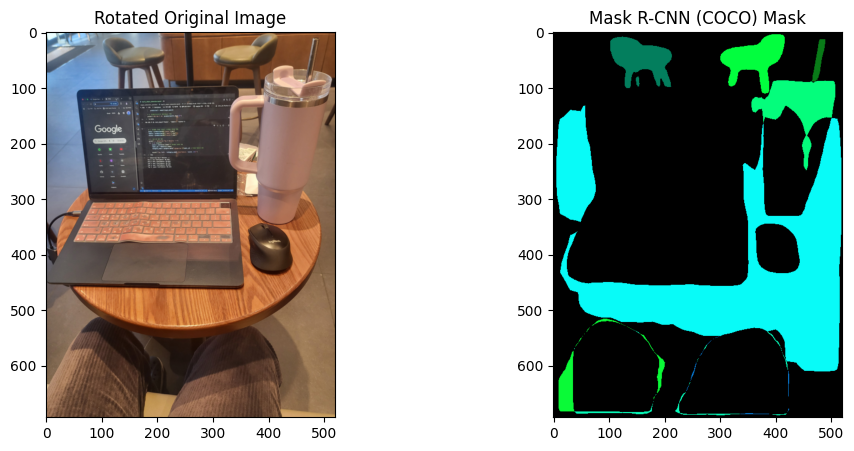

In [12]:
# Improved Version 3
# Confidence Threshold 하향 조정(0.7-> 0.5)
# COCO model(80개 클래스)를 사용
# image의 방향도 정방향으로 회전시킨 후 Improved Version 1과 결과 비교

import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn, MaskRCNN_ResNet50_FPN_Weights
from torchvision.utils import draw_segmentation_masks
import torchvision.transforms.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import os

# 1. 모델 준비 (COCO 기반 Mask R-CNN)(업데이트된 부분)
device = torch.device("cpu")
weights = MaskRCNN_ResNet50_FPN_Weights.DEFAULT
model = maskrcnn_resnet50_fpn(weights=weights).to(device)
model.eval()

# 2. 이미지 로드 및 회전 적용 (기존과 동일)
img_path = "../images/object_detection/my_photo.jpeg"
# expand=True(회전 시 이미지가 잘려나가지 않게 보존)
input_image = Image.open(img_path).convert("RGB").rotate(-90, expand=True) 

# 변인 통제: 실험 1과 완전히 동일한 전처리 크기 적용
resize_transform = transforms.Resize(520)
input_image = resize_transform(input_image)

# 3. 전처리 (Mask R-CNN용 텐서 변환)
image_tensor = F.pil_to_tensor(input_image)
input_batch = F.convert_image_dtype(image_tensor, dtype=torch.float).unsqueeze(0).to(device)

# 4. 추론
with torch.no_grad():
    output = model(input_batch)[0]

# 5. 신뢰도 0.5 이상 필터링 및 시각화
threshold = 0.5 # 커트라인 하향 조정(0.7 -> 0.5)
keep_indices = output['scores'] > threshold
masks = output['masks'][keep_indices].squeeze(1) > 0.5

# 밝고 눈에 띄는 색상 팔레트 직접 정의 (PIL Color 이름 지원)
# 개수가 부족하면 반복해서 사용됩니다.
bright_colors = [
    "cyan",    # 민트색
    "lime",    # 형광 연두색
    "magenta", # 자주색
    "yellow",  # 노란색
    "red",     # 빨간색
    "dodgerblue" # 밝은 파란색
]

# 기존 버전의 포맷 유지를 위해 검은색 배경 생성
_, H, W = image_tensor.shape
black_canvas = torch.zeros((3, H, W), dtype=torch.uint8)

# mask를 불투명도 100%(alpha=1.0)으로 색칠
rgb_mask_tensor = draw_segmentation_masks(black_canvas, masks=masks, alpha=1.0)
rgb_mask_image = F.to_pil_image(rgb_mask_tensor)

# 6. 결과 출력 및 저장
save_dir = "../images/semantic_segmentation"
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(12, 5))

# Left: 회전된 원본 이미지
plt.subplot(1, 2, 1)
plt.title("Rotated Original Image")
plt.imshow(input_image)

# Right: 검은 배경의 COCO mask
plt.subplot(1, 2, 2)
plt.title("Mask R-CNN (COCO) Mask")
plt.imshow(rgb_mask_image)

# 파일 저장
save_path = os.path.join(save_dir, "result_maskrcnn_coco_rotated_lower_threshold.png")
plt.savefig(save_path, bbox_inches='tight', dpi=300)

print(f"이미지가 저장되었습니다: {save_path}")
plt.show()

Improved Version 3가 오히려 Version 2보다 악화됨.
예상 원인: Overlapping Prediction

-> Mask R-CNN은 근본적으로 적절한 모델이 아니었음.
-> 원인: DeepLabV3와 Mask R-CNN의 구조적 차이

DeepLabV3: 픽셀마다 들여다보며 경계를 나눔
-> 누끼가 매우 정교함

Mask R-CNN: 네모난 Bounding Box를 그린 후 그 내부에 대략적으로 마스크를 그림. 해당 사진처럼 화면 전체를 덮는 비정형 사물(테이블)이나 시점이 왜곡되어 있으면(다리를 1인칭으로 찍음) 박스 모양이 분석하기에 부적합하게 형성됨. 특히 다리의 경우 모델이 학습한 3인칭 데이터셋과 전혀 다른 모습임.
-> 누끼의 정교함이 떨어짐